In [213]:
import kagglehub
import os
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, confusion_matrix, classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.ensemble import BaggingClassifier
from imblearn.ensemble import BalancedBaggingClassifier
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

In [196]:
path = kagglehub.dataset_download("fedesoriano/stroke-prediction-dataset")
df = pd.read_csv(os.path.join(path, "healthcare-dataset-stroke-data.csv"))
df.head(5)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [197]:
df = df.drop(columns='id')

In [198]:
#Let's make sure to give values to the variables so we can easily apply our models later.
#Also making a copy to use the categorical values without issues when plotting the graphs, the following will be used for models.

df_og = df.copy()
df['gender'] = df['gender'].replace({'Male':0,'Female':1,'Other':-1})
df['Residence_type'] = df['Residence_type'].replace({'Rural':0,'Urban':1})
df['work_type'] = df['work_type'].replace({'Private':0,'Self-employed':1,'Govt_job':2,'children':-1,'Never_worked':-2})
df['hypertension'] = df['hypertension'].replace({'No':0, 'Yes':1})
df['heart_disease'] = df['heart_disease'].replace({'No':0, 'Yes':1})
df['ever_married'] = df['ever_married'].replace({'No':0, 'Yes':1})
df['smoking_status'] = df['smoking_status'].replace({'Unknown':np.nan, 'smokes':2, 'formerly smoked':1, 'never smoked':0})
df.isnull().sum()

gender                  0
age                     0
hypertension            0
heart_disease           0
ever_married            0
work_type               0
Residence_type          0
avg_glucose_level       0
bmi                   201
smoking_status       1544
stroke                  0
dtype: int64

In [199]:
#Let's replace those missing values with KNNImputer

imputer = KNNImputer(weights='distance')
df[['bmi']] = imputer.fit_transform(df[['bmi']]).round(2)
df[['smoking_status']] = imputer.fit_transform(df[['smoking_status']]).round()
df.isnull().sum()
df.head(5)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,67.0,0,1,1,0,1,228.69,36.60,1.0,1
1,1,61.0,0,0,1,1,0,202.21,28.89,0.0,1
2,0,80.0,0,1,1,0,0,105.92,32.50,0.0,1
3,1,49.0,0,0,1,0,1,171.23,34.40,2.0,1
4,1,79.0,1,0,1,1,0,174.12,24.00,0.0,1


In [200]:
#Let's separate the numerical and categorical variables in order to start analysing the dataset

numerical_vars = ['age', 'avg_glucose_level', 'bmi']
categorical_vars = [col for col in df_og.columns if col not in numerical_vars and col != 'stroke']

# Plotting the Data

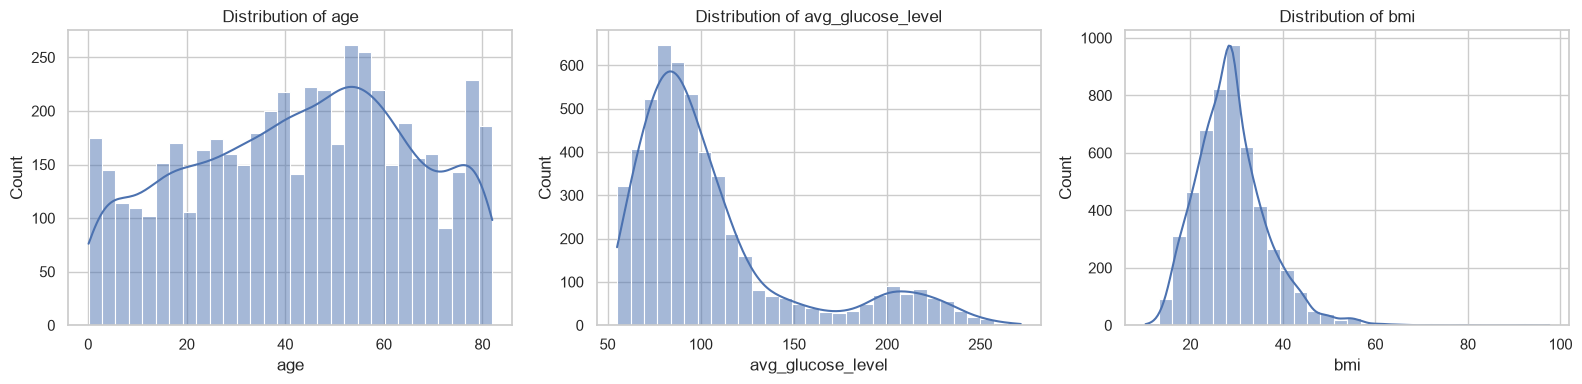

In [201]:
sns.set_theme(style="whitegrid", context="notebook", palette="deep")

fig, axes = plt.subplots(1, len(numerical_vars), figsize=(16, 4))

for i, col in enumerate(numerical_vars):
    sns.histplot(data=df, x=col, bins=30, kde=True, ax=axes[i])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

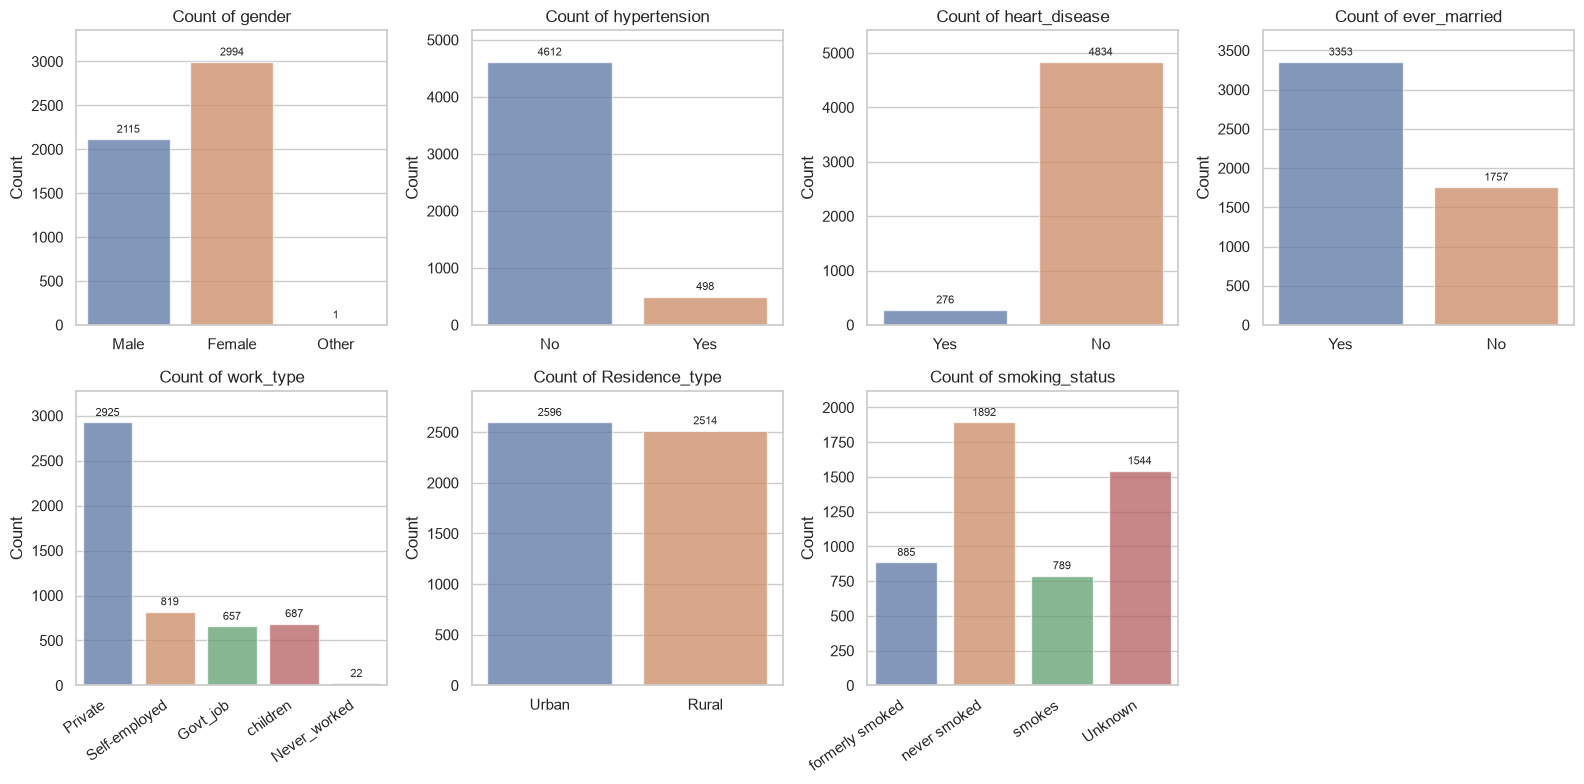

In [202]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_vars):
    plot_series = df_og[col]
    if set(plot_series.dropna().unique()).issubset({0, 1}):
        plot_series = plot_series.map({0: "No", 1: "Yes"})

    sns.countplot(x=plot_series, ax=axes[i], hue=plot_series, alpha=0.75, legend=False)
    axes[i].set_title(f"Count of {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

    for container in axes[i].containers:
        labels = [
            f"{bar.get_height():.0f}" if bar.get_height() > 0 else ""
            for bar in container
        ]
        axes[i].bar_label(container, labels=labels, padding=3, fontsize=8)
    axes[i].margins(y=0.12)

    tick_labels = axes[i].get_xticklabels()
    if any(len(label.get_text()) > 8 for label in tick_labels):
        axes[i].tick_params(axis="x", labelrotation=35)
        for label in tick_labels:
            label.set_ha("right")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

# Plotting Data vs Stroke

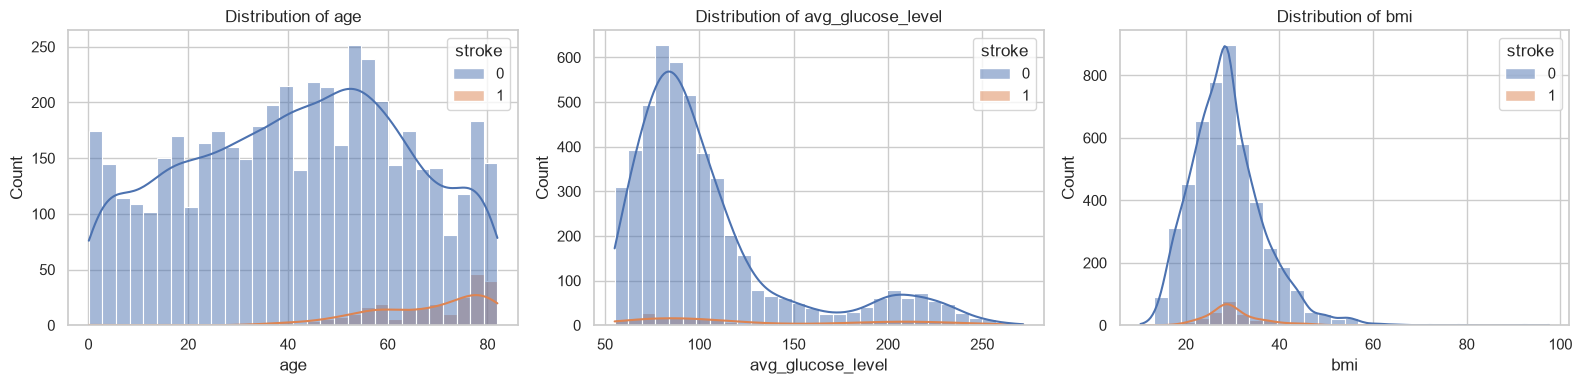

In [203]:
fig, axes = plt.subplots(1, len(numerical_vars), figsize=(16, 4))

for i, col in enumerate(numerical_vars):
    sns.histplot(data=df, x=col, bins=30, kde=True, ax=axes[i], hue=df['stroke'])
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

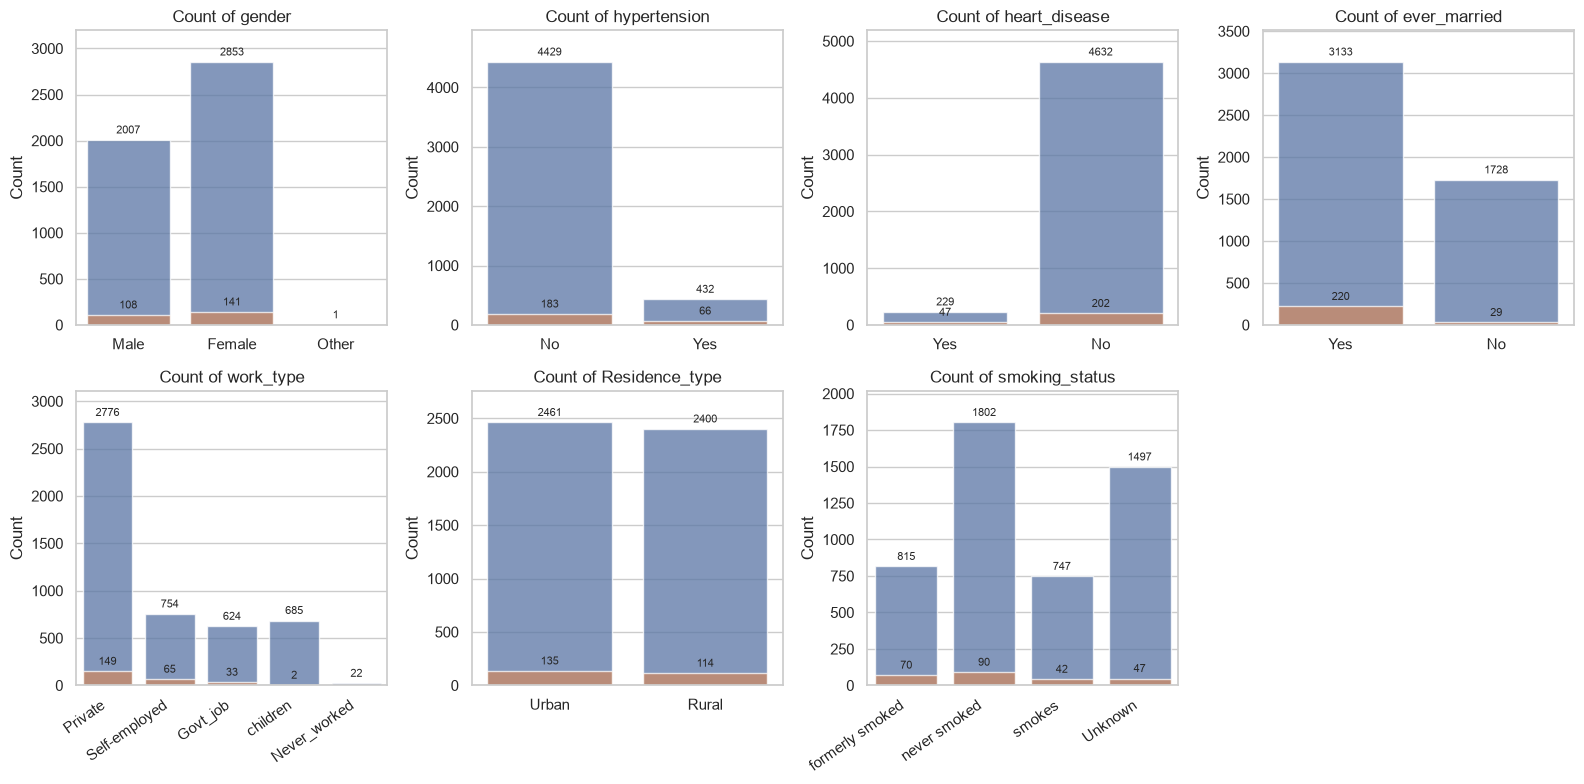

In [204]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_vars):
    plot_series = df_og[col]
    if set(plot_series.dropna().unique()).issubset({0, 1}):
        plot_series = plot_series.map({0: "No", 1: "Yes"})

    sns.countplot(
        x=plot_series,
        ax=axes[i],
        hue=df["stroke"],
        dodge=False,
        alpha=0.75,
        legend=False,
    )
    
    axes[i].set_title(f"Count of {col}")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Count")

    for container in axes[i].containers:
        labels = [
            f"{bar.get_height():.0f}" if bar.get_height() > 0 else ""
            for bar in container
        ]
        axes[i].bar_label(container, labels=labels, padding=3, fontsize=8)
    
    axes[i].margins(y=0.12)

    tick_labels = axes[i].get_xticklabels()
    if any(len(label.get_text()) > 8 for label in tick_labels):
        axes[i].tick_params(axis="x", labelrotation=35)
        for label in tick_labels:
            label.set_ha("right")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.show()

# Observations

1. We can clearly see that there seems to be a higher chance of stroke at higher ages and it weirdly seems that being married is slightly more prone to strokes aswell.
2. All other variables look fairly equal, even though we see way more cases of stroke if there's no heart disease that's simply because there's way more cases of no heart diseases. We will analyse that shortly.

# Correlation heatmap

In [205]:
#Needed to reverse map the values I changed at the beginning in order to get which value of the variable affected

reverse_maps = {
    'gender': {0: 'Male', 1: 'Female', -1: 'Other'},
    'Residence_type': {0: 'Rural', 1: 'Urban'},
    'work_type': {0: 'Private', 1: 'Self-employed', 2: 'Govt_job', -1: 'children', -2: 'Never_worked'},
    'hypertension': {0: 'No', 1: 'Yes'},
    'heart_disease': {0: 'No', 1: 'Yes'},
    'ever_married': {0: 'No', 1: 'Yes'},
    'smoking_status': {0: 'never smoked', 1: 'formerly smoked', 2: 'smokes'}}

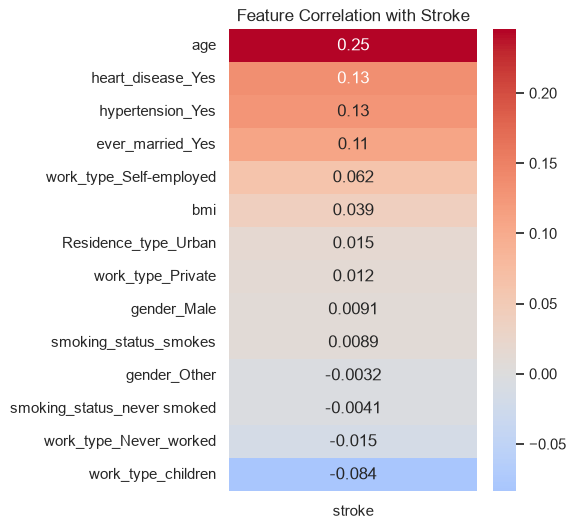

In [206]:
#Need to onehoe encode, also dropping avg_glucose_level since it wouldn't make sense unless I create intervals of values for it (I think)

df_temp = df.copy()
df_temp = df_temp.drop(columns='avg_glucose_level')
for col, mapping in reverse_maps.items():
    df_temp[col] = df_temp[col].map(mapping)

df_encoded = pd.get_dummies(df_temp, columns=list(reverse_maps.keys()), drop_first=True)

stroke_corr = (df_encoded.corr()[["stroke"]]
               .drop(index="stroke")
               .sort_values(by="stroke", ascending=False))

plt.figure(figsize=(4, 6))
sns.heatmap(stroke_corr, cmap="coolwarm", center=0, annot=True)
plt.title("Feature Correlation with Stroke")
plt.show()

The top 5 correlations with having a stroke seem to be:
1. Having a prior heart disease
2. Having hypertension
3. Having been married
4. Working a self-employed job

These last two features being present seem weird, it could be due to stress, possibly.

# Models

1. It'll be very important to avoid false negatives in this scenario. Also it is a very unbalanced dataset.
2. Let's also creative a function for evaluating to avoid repeating many lines of code.
3. No strokes = 4861, Strokes = 249

In [207]:
def evaluate_model(model, y_true, y_pred):
    print(f"{model}")
    print(f"Model Accuracy: {accuracy_score(y_true, y_pred):.2%}\n")
    print(f"Confusion Matrix:\n{confusion_matrix(y_true, y_pred)}\n")
    print("Classification Report:\n", classification_report(y_true, y_pred))

In [208]:
X = df.drop(columns='stroke')
X = pd.get_dummies(
    X,
    columns=X.select_dtypes(include='object').columns,
    drop_first=True,
    dtype=int,)
y = df['stroke']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [230]:
y_test.value_counts()

stroke
0    1591
1      96
Name: count, dtype: int64

### Regression
We will first try with a simple regression with class_weight to penalize missclassifications of the imbalanced group, therefore making the ratio of yes to no data fairer

In [209]:
reg_model = LogisticRegression(max_iter=1000, class_weight='balanced')
reg_model.fit(X_train, y_train)

reg_model_pred = reg_model.predict(X_test)
evaluate_model('Regression', y_test, reg_model_pred)

Regression
Model Accuracy: 74.21%

Confusion Matrix:
[[1180  411]
 [  24   72]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.74      0.84      1591
           1       0.15      0.75      0.25        96

    accuracy                           0.74      1687
   macro avg       0.56      0.75      0.55      1687
weighted avg       0.93      0.74      0.81      1687



c:\Users\tomef\Documents\Stroke Prediction Dataset\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


As we can see it overguessed on the false alarms (FP), hence the 0.15 precision on "stroke" predictions, but it is important to note that in this dataset we want to minimize false negatives (FN), which we got 22 of, not bad for a simple regression. FN are bad because we are saying the patient is fine and they are indeed having a stroke.

### Random Forest

##### Base Random Forest

In [210]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

rf_model_pred = rf_model.predict(X_test)
evaluate_model('Random Forest', y_test, rf_model_pred)

Random Forest
Model Accuracy: 94.25%

Confusion Matrix:
[[1590    1]
 [  96    0]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97      1591
           1       0.00      0.00      0.00        96

    accuracy                           0.94      1687
   macro avg       0.47      0.50      0.49      1687
weighted avg       0.89      0.94      0.92      1687



##### Balanced Random Forest

In [211]:
brf_model = BalancedRandomForestClassifier(random_state=42)
brf_model.fit(X_train, y_train)

brf_model_pred = brf_model.predict(X_test)
evaluate_model('Balanced Random Forest', y_test, brf_model_pred)

Balanced Random Forest
Model Accuracy: 81.09%

Confusion Matrix:
[[1297  294]
 [  25   71]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.82      0.89      1591
           1       0.19      0.74      0.31        96

    accuracy                           0.81      1687
   macro avg       0.59      0.78      0.60      1687
weighted avg       0.94      0.81      0.86      1687



### XGBoost

In [212]:
xgboost_model = XGBClassifier(enable_categorical=True)
xgboost_model.fit(X_train, y_train)

xgboost_model_pred = xgboost_model.predict(X_test)
evaluate_model('XGBoost', y_test, xgboost_model_pred)

XGBoost
Model Accuracy: 94.13%

Confusion Matrix:
[[1578   13]
 [  86   10]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97      1591
           1       0.43      0.10      0.17        96

    accuracy                           0.94      1687
   macro avg       0.69      0.55      0.57      1687
weighted avg       0.92      0.94      0.92      1687



### SMOTE (Synthetic Minority Over-sampling Technique)

1. The results from previous models were quite bad, which was expected, we will now try using SMOTE and retrying the models to compare results

In [218]:
smote = SMOTE(sampling_strategy='minority', random_state=42)
X_train_smote , y_train_smote = smote.fit_resample(X_train, y_train)

##### (SMOTE) Logistic Regression

In [220]:
reg_model_smote = reg_model.fit(X_train_smote, y_train_smote)

reg_model_smote_pred = reg_model_smote.predict(X_test)
evaluate_model('(SMOTE) Logistic Regression', y_test, reg_model_smote_pred)

(SMOTE) Logistic Regression
Model Accuracy: 88.92%

Confusion Matrix:
[[1475  116]
 [  71   25]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.93      0.94      1591
           1       0.18      0.26      0.21        96

    accuracy                           0.89      1687
   macro avg       0.57      0.59      0.58      1687
weighted avg       0.91      0.89      0.90      1687



##### (SMOTE) Base Random Forest

In [221]:
rf_model_smote = rf_model.fit(X_train_smote, y_train_smote)

rf_model_smote_pred = rf_model_smote.predict(X_test)
evaluate_model('(SMOTE) Base Random Forest', y_test, rf_model_smote_pred)

(SMOTE) Base Random Forest
Model Accuracy: 93.60%

Confusion Matrix:
[[1574   17]
 [  91    5]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97      1591
           1       0.23      0.05      0.08        96

    accuracy                           0.94      1687
   macro avg       0.59      0.52      0.53      1687
weighted avg       0.90      0.94      0.92      1687



##### (SMOTE) Balanced Random Forest

In [222]:
brf_model_smote = brf_model.fit(X_train_smote, y_train_smote)

brf_model_smote_pred = brf_model_smote.predict(X_test)
evaluate_model('(SMOTE) Balanced Random Forest', y_test, brf_model_smote_pred)

(SMOTE) Balanced Random Forest
Model Accuracy: 93.12%

Confusion Matrix:
[[1568   23]
 [  93    3]]

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.96      1591
           1       0.12      0.03      0.05        96

    accuracy                           0.93      1687
   macro avg       0.53      0.51      0.51      1687
weighted avg       0.90      0.93      0.91      1687



##### (SMOTE) XGBoost

In [223]:
xgboost_model_smote = xgboost_model.fit(X_train_smote, y_train_smote)

xgboost_model_smote_pred = xgboost_model_smote.predict(X_test)
evaluate_model('(SMOTE) XGBoost', y_test, xgboost_model_smote_pred)

(SMOTE) XGBoost
Model Accuracy: 92.12%

Confusion Matrix:
[[1546   45]
 [  88    8]]

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.97      0.96      1591
           1       0.15      0.08      0.11        96

    accuracy                           0.92      1687
   macro avg       0.55      0.53      0.53      1687
weighted avg       0.90      0.92      0.91      1687

